In [2]:
#File: kepler.ipynb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt

In [13]:
df = pd.read_csv("../../course_assignments/homework9/solar_system.csv")
df.shape #20 rows and 11 columns
print(df.head())
df.tail()
print(df.columns)
print(df.iloc[:, 0])

                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  
Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')
0                  Mass (10^24kg)
1                   Diameter (km)
2                Density (kg/m^3)
3                 Gravity (m/s^2)
4          Escape Velocity (km/s)
5         Rotation Period (hours)
6

In [14]:
orbital_period = df.iloc[10,1:].astype(float)
perihelion = df.iloc[8, 1:].astype(float)
aphelion = df.iloc[9, 1:].astype(float)

Perihelion: This is the point in an objects orbit where it is closest to the sun

Aphelion: This is the point in an objects orbit where it is furthest from the sun

Semi-Major Axis: this is a disance equal to half of the longest diameter in the ellipse

In [15]:
semi_major_axis = (perihelion + aphelion) / 2 # units of 10^6 km]
semi_major_axis = pd.Series(semi_major_axis)

print(semi_major_axis)
df_new = pd.concat([df, semi_major_axis.to_frame().T], ignore_index = True, axis = 0)
df_new.iloc[20,0] = 'Semi Major Axis (10^6 km)'
df_new.shape #21 rows with 11 columns

Mercury      57.9000
Venus       108.2000
Earth       149.6000
Moon          0.3845
Mars        228.0000
Jupiter     778.5000
Saturn     1432.0500
Uranus     2867.0500
Neptune    4515.0000
Pluto      5906.3500
dtype: float64


(21, 11)

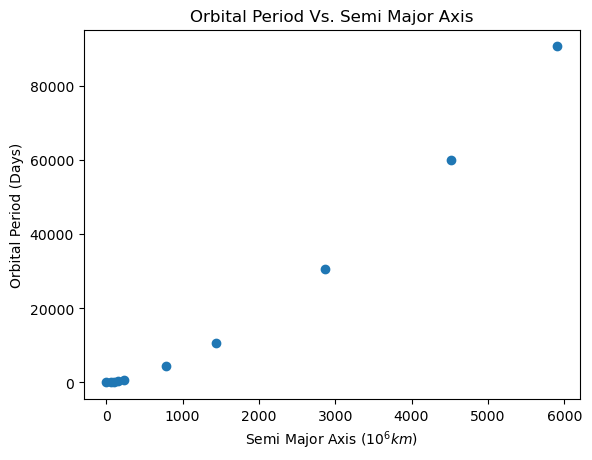

In [16]:
plt.figure()

plt.scatter(semi_major_axis, orbital_period)

plt.title("Orbital Period Vs. Semi Major Axis")
plt.xlabel(r"Semi Major Axis ($10^6 km$)")
plt.ylabel("Orbital Period (Days)")

plt.show()

In [47]:
def keplers_third_law(a, m):
    return m * a ** 1.5

p0 = [1]
popt, pcov = opt.curve_fit(keplers_third_law, semi_major_axis, orbital_period, p0=p0)
m_fit = popt[0]

period_th = keplers_third_law(semi_major_axis, m_fit)
# print(orbital_period)
# print(period_th)

residuals = orbital_period - period_th
chi2 = np.sum(residuals**2)
dof = len(semi_major_axis) - len(popt)
chi2_red = chi2/dof

print(m_fit)
print(chi2_red)

0.19879981918623565
41276.70608939402


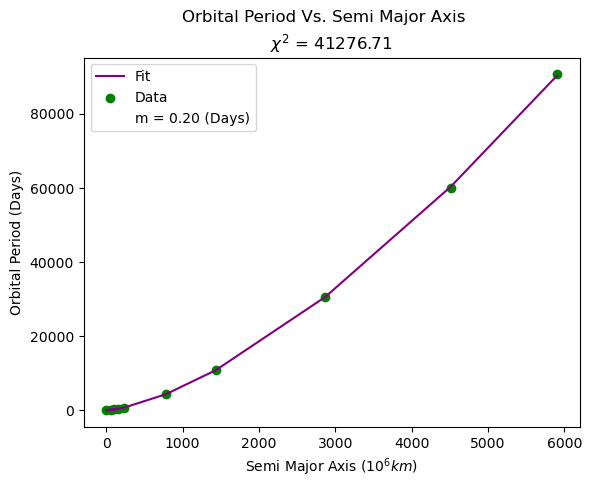

In [50]:
plt.figure()

plt.plot(semi_major_axis, keplers_third_law(semi_major_axis, m_fit), c = 'purple', label = "Fit")
plt.scatter(semi_major_axis, orbital_period, c = 'green', label = "Data")
plt.plot(0, 0,linestyle = ' ', label = f'm = {m_fit:.2f} (Days)')

plt.suptitle("Orbital Period Vs. Semi Major Axis")
plt.title(f"$\chi^2$ = {chi2_red:.2f}")
plt.xlabel(r"Semi Major Axis ($10^6 km$)")
plt.ylabel("Orbital Period (Days)")
plt.legend()

plt.show()

In [51]:
df_new.to_csv("kepler.csv", index = False)